# COVID-19 Country Risk Clustering Based on Death Rates

## Objective

The goal of this analysis is to classify countries based on their COVID-19 death rate profiles using unsupervised machine learning. This can help identify clusters of countries with similar COVID-19 risk levels.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [3]:
df = pd.read_csv("C:/Users/saade/OneDrive/Desktop/CDSP/ET6-CDSP-group-09-repo/1_datasets/cleaned_datasets/covid_all_countries_cleaned.csv")


### Display dataset info

In [4]:
print(f"Total countries: {df.shape[0]}")
print(df.head())

Total countries: 204
                            Country  COVID_Deaths_Rate         upper  \
0  Lao People's Democratic Republic       6.867837e-11  6.867837e-11   
1                         Sri Lanka       2.820345e+00  2.820345e+00   
2                              Fiji       8.084884e+00  1.685940e+01   
3                             Samoa       2.370317e-09  2.370317e-09   
4                          Malaysia       1.516114e+00  2.286782e+00   

          lower  
0  6.867837e-11  
1  2.820345e+00  
2  2.008246e+00  
3  2.370317e-09  
4  8.061217e-01  


### Show all countries

In [5]:
print("List of all countries:")
print(df["Country"].sort_values().to_list())

List of all countries:
['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra', 'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan', 'Bolivia (Plurinational State of)', 'Bosnia and Herzegovina', 'Botswana', 'Brazil', 'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi', 'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Central African Republic', 'Chad', 'Chile', 'China', 'Colombia', 'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', 'Croatia', 'Cuba', 'Cyprus', 'Czechia', "Côte d'Ivoire", "Democratic People's Republic of Korea", 'Democratic Republic of the Congo', 'Denmark', 'Djibouti', 'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt', 'El Salvador', 'Equatorial Guinea', 'Eritrea', 'Estonia', 'Eswatini', 'Ethiopia', 'Fiji', 'Finland', 'France', 'Gabon', 'Gambia', 'Georgia', 'Germany', 'Ghana', 'Greece', 'Greenland', 'G

### Feature selection and scaling

In [6]:
features = df[["COVID_Deaths_Rate", "upper", "lower"]]
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### KMeans clustering into 3 groups

In [7]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(scaled_features)

c:\Users\saade\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\saade\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "c:\Users\saade\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\saade\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\saade\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.CreatePro

### Reorder clusters by ascending average death rate

In [8]:
cluster_means = df.groupby("Cluster")["COVID_Deaths_Rate"].mean().sort_values()
cluster_order = {old: new for new, old in enumerate(cluster_means.index)}
df["Cluster"] = df["Cluster"].map(cluster_order)

### Visualize clusters with boxplot

C:\Users\saade\AppData\Local\Temp\ipykernel_25572\1561157551.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Cluster", y="COVID_Deaths_Rate", data=df, palette="Set2")


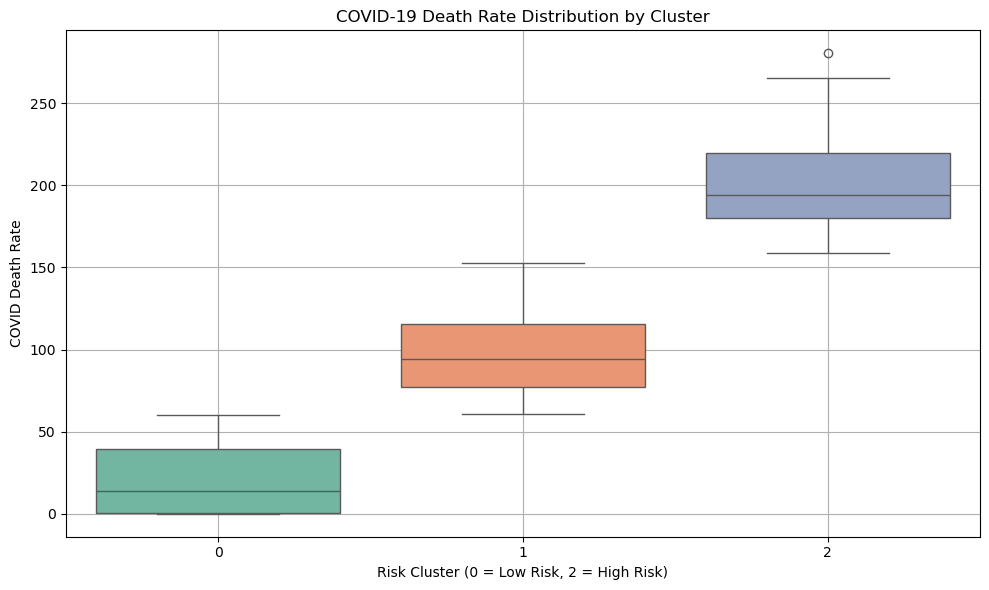

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(x="Cluster", y="COVID_Deaths_Rate", data=df, palette="Set2")
plt.title("COVID-19 Death Rate Distribution by Cluster")
plt.xlabel("Risk Cluster (0 = Low Risk, 2 = High Risk)")
plt.ylabel("COVID Death Rate")
plt.grid(True)
plt.tight_layout()
plt.show()

### World map visualization with Plotly

In [10]:
import plotly.express as px

# Map numeric cluster to readable label
cluster_labels = {
    0: "Low Risk",
    1: "Medium Risk",
    2: "High Risk"
}
df["Risk_Level"] = df["Cluster"].map(cluster_labels)

# Create choropleth map
fig = px.choropleth(df,
                    locations="Country",
                    locationmode="country names",
                    color="Risk_Level",
                    title="COVID-19 Risk Clusters by Country",
                    color_discrete_map={
                        "Low Risk": "green",
                        "Medium Risk": "orange",
                        "High Risk": "red"
                    },
                    template="plotly_white")

fig.update_geos(showframe=False, showcoastlines=False)
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})
fig.show()

### Show all countries, sorted by death rate (high to low)

In [11]:
df_sorted = df.sort_values(by="COVID_Deaths_Rate", ascending=False).reset_index(drop=True)
print(df_sorted[["Country", "COVID_Deaths_Rate", "Cluster"]])

                              Country  COVID_Deaths_Rate  Cluster
0    Bolivia (Plurinational State of)       2.804516e+02        2
1                                Peru       2.656561e+02        2
2                            Bulgaria       2.403264e+02        2
3                     North Macedonia       2.218813e+02        2
4                              Mexico       2.121229e+02        2
..                                ...                ...      ...
199                   Solomon Islands       7.456992e-10        0
200                            Bhutan       6.593803e-10        0
201                       Timor-Leste       3.651418e-10        0
202  Lao People's Democratic Republic       6.867837e-11        0
203                          Cambodia       2.970584e-11        0

[204 rows x 3 columns]


### Save full sorted dataset with clusters

In [12]:
df_sorted.to_csv("covid_clustered_all_countries_sorted.csv", index=False)

In [13]:
print("✔️ Clustered data saved as 'covid_clustered_all_countries_sorted.csv'")

✔️ Clustered data saved as 'covid_clustered_all_countries_sorted.csv'
